In [1]:
# Classifying Shooting Incident Fatality
#Machine Learning Classification Project

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore")

In [3]:
## Load Dataset

In [4]:
df = pd.read_csv("NYPD_Shooting_Incident_Data__Historic_.csv")

df.head()

,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,JURISDICTION_CODE,LOC_CLASSFCTN_DESC,LOCATION_DESC,STATISTICAL_MURDER_FLAG,...,PERP_SEX,PERP_RACE,VIC_AGE_GROUP,VIC_SEX,VIC_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lon_Lat
0,228798151,05/27/2021,21:30:00,QUEENS,NaN,105,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.058925e+06,180924.000000,40.662965,-73.730839,POINT (-73.73083868899994 40.662964620000025)
1,137471050,06/27/2014,17:40:00,BRONX,NaN,40,0.0,NaN,NaN,False,...,NaN,NaN,18-24,M,BLACK,1.005028e+06,234516.000000,40.810352,-73.924942,POINT (-73.92494232599995 40.81035186300006)
2,147998800,11/21/2015,03:56:00,QUEENS,NaN,108,0.0,NaN,NaN,True,...,NaN,NaN,25-44,M,WHITE,1.007668e+06,209836.531250,40.742607,-73.915492,POINT (-73.91549174199997 40.74260663300004)
3,146837977,10/09/2015,18:30:00,BRONX,NaN,44,0.0,NaN,NaN,False,...,NaN,NaN,<18,M,WHITE HISPANIC,1.006537e+06,244511.140625,40.837782,-73.919457,POINT (-73.91945661499994 40.83778200300003)
4,58921844,02/19/2009,22:58:00,BRONX,NaN,47,0.0,NaN,NaN,True,...,M,BLACK,45-64,M,BLACK,1.024922e+06,262189.406250,40.886238,-73.852910,POINT (-73.85290950899997 40.88623791800006)


In [5]:
df.columns

Index(['INCIDENT_KEY', 'OCCUR_DATE', 'OCCUR_TIME', 'BORO', 'LOC_OF_OCCUR_DESC',
       'PRECINCT', 'JURISDICTION_CODE', 'LOC_CLASSFCTN_DESC', 'LOCATION_DESC',
       'STATISTICAL_MURDER_FLAG', 'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE',
       'VIC_AGE_GROUP', 'VIC_SEX', 'VIC_RACE', 'X_COORD_CD', 'Y_COORD_CD',
       'Latitude', 'Longitude', 'Lon_Lat'],
      dtype='object')

In [6]:
## Data Cleaning

In [7]:
drop_cols = [
    "INCIDENT_KEY",
    "X_COORD_CD",
    "Y_COORD_CD",
    "Latitude",
    "Longitude",
    "Lon_Lat"
]

df = df.drop(columns=drop_cols, errors="ignore")

In [8]:
## Feature Engineering

In [9]:
df["OCCUR_DATE"] = pd.to_datetime(df["OCCUR_DATE"])

df["year"] = df["OCCUR_DATE"].dt.year
df["month"] = df["OCCUR_DATE"].dt.month
df["day"] = df["OCCUR_DATE"].dt.day
df["dayofweek"] = df["OCCUR_DATE"].dt.dayofweek

df["is_weekend"] = df["dayofweek"].apply(lambda x: 1 if x>=5 else 0)

df["hour"] = df["OCCUR_TIME"].str[:2].astype(int)

In [10]:
## Target Encoding

In [11]:
df["STATISTICAL_MURDER_FLAG"] = df["STATISTICAL_MURDER_FLAG"].map({
    True:1,
    False:0,
    "TRUE":1,
    "FALSE":0,
    "true":1,
    "false":0
})

In [12]:
## Encode categorical columns

In [13]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [14]:
## EDA

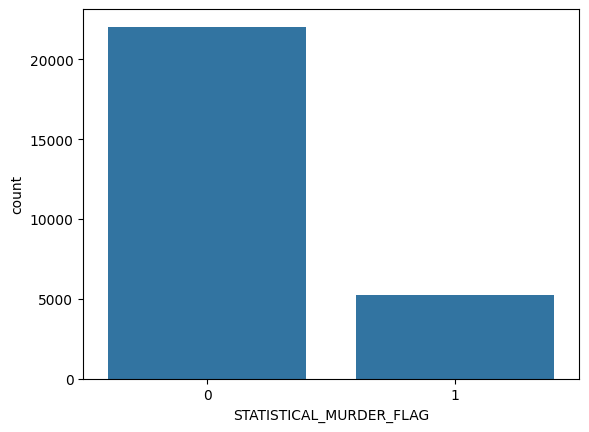

In [15]:
sns.countplot(x="STATISTICAL_MURDER_FLAG", data=df)
plt.show()

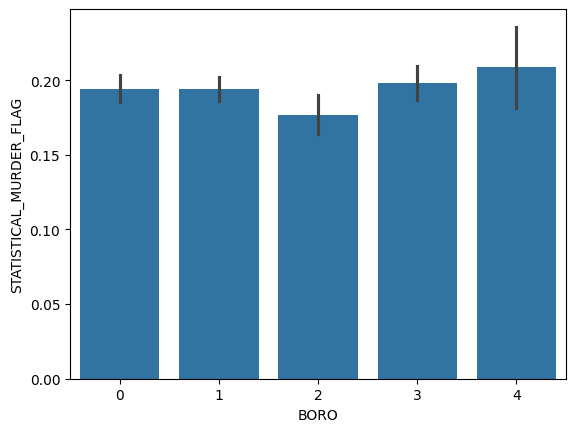

In [16]:
sns.barplot(
    x="BORO",
    y="STATISTICAL_MURDER_FLAG",
    data=df
)
plt.show()

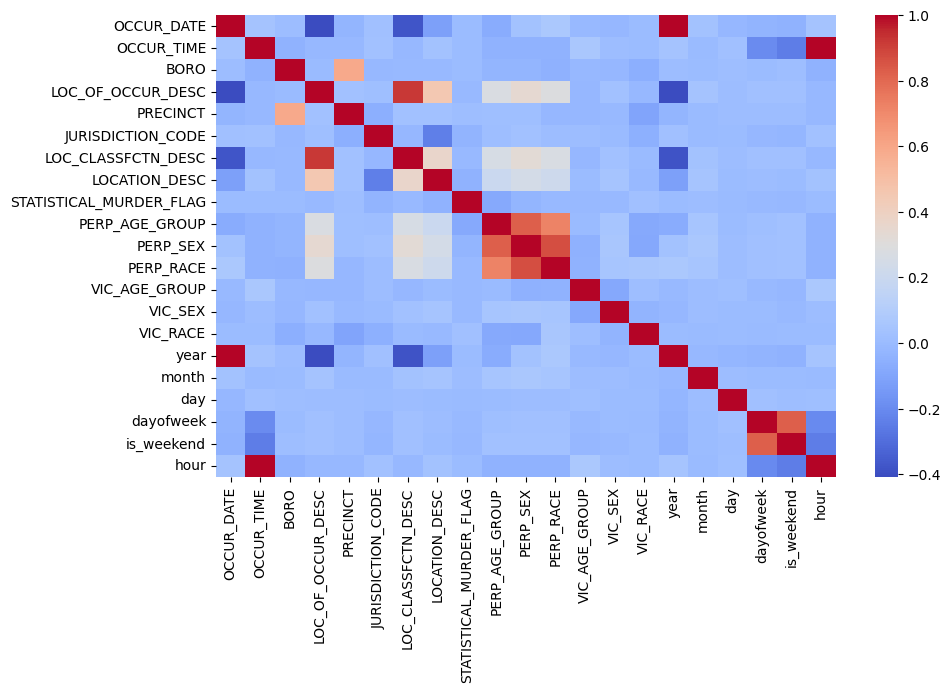

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

In [28]:
# fill missing values

for col in df.columns:
    if df[col].dtype == "float64" or df[col].dtype == "int64":
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()

OCCUR_DATE                 0
OCCUR_TIME                 0
BORO                       0
LOC_OF_OCCUR_DESC          0
PRECINCT                   0
JURISDICTION_CODE          0
LOC_CLASSFCTN_DESC         0
LOCATION_DESC              0
STATISTICAL_MURDER_FLAG    0
PERP_AGE_GROUP             0
PERP_SEX                   0
PERP_RACE                  0
VIC_AGE_GROUP              0
VIC_SEX                    0
VIC_RACE                   0
year                       0
month                      0
day                        0
dayofweek                  0
is_weekend                 0
hour                       0
dtype: int64

In [18]:
## Train Test Split

In [29]:
X = df.drop("STATISTICAL_MURDER_FLAG", axis=1)
y = df["STATISTICAL_MURDER_FLAG"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
# keep only numeric columns

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

num_cols = X_train.select_dtypes(include=["int64","float64","int32","float32"]).columns

X_train = X_train[num_cols]
X_test = X_test[num_cols]

print("Using columns:", num_cols)

Using columns: Index(['OCCUR_TIME', 'BORO', 'LOC_OF_OCCUR_DESC', 'PRECINCT',
       'JURISDICTION_CODE', 'LOC_CLASSFCTN_DESC', 'LOCATION_DESC',
       'PERP_AGE_GROUP', 'PERP_SEX', 'PERP_RACE', 'VIC_AGE_GROUP', 'VIC_SEX',
       'VIC_RACE', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'hour'],
      dtype='object')


In [24]:
#Scalling

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
## Models

In [32]:
models = {
    "Logistic": LogisticRegression(),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "GradientBoost": GradientBoostingClassifier()
}

In [33]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1"]
)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic,0.807249,0.000000,0.000000,0.000000
1,DecisionTree,0.704558,0.234123,0.234568,0.234345
2,RandomForest,0.778693,0.273256,0.089269,0.134574
3,KNN,0.773568,0.266497,0.099715,0.145128
4,SVM,0.807066,0.000000,0.000000,0.000000
5,GradientBoost,0.811093,0.690909,0.036087,0.068592


In [34]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,None]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring="f1"
)

grid.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [5, 10, ...], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [35]:
best_model = grid.best_estimator_

pred = best_model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.81      0.94      0.87      4410
           1       0.29      0.10      0.15      1053

    accuracy                           0.78      5463
   macro avg       0.55      0.52      0.51      5463
weighted avg       0.71      0.78      0.73      5463



In [37]:
feat = pd.DataFrame({
    "Feature": num_cols,
    "Importance": best_model.feature_importances_
})

feat = feat.sort_values(
    by="Importance",
    ascending=False
)

feat.head(10)

,Feature,Importance
0,OCCUR_TIME,0.143745
15,day,0.115887
3,PRECINCT,0.113015
13,year,0.110395
14,month,0.090756
18,hour,0.079799
16,dayofweek,0.065003
10,VIC_AGE_GROUP,0.044019
7,PERP_AGE_GROUP,0.042516
6,LOCATION_DESC,0.040468


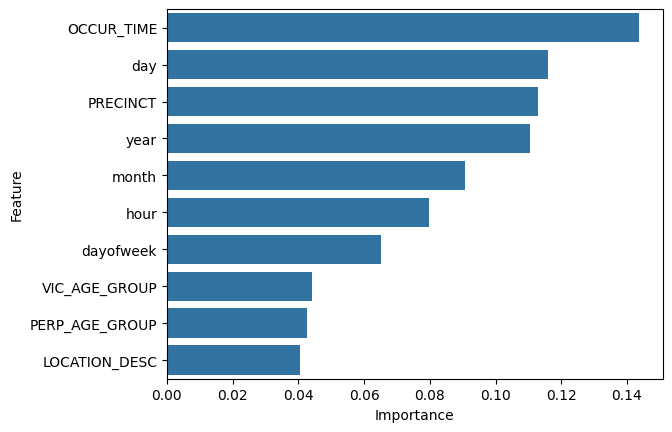

In [38]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=feat.head(10)
)

plt.show()

In [39]:
## Conclusion

#Random Forest performed best.
#Model identifies factors affecting fatal incidents.
#Useful for law enforcement planning.